In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np, matplotlib.pyplot as plt, os, math, random
from PIL import Image, ImageDraw

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG, HOLE, EPOCHS, BS, LR = 128, 64, 100, 32, 2e-4
print('device:', device)

device: cuda


In [2]:
# ── Generate sample dataset (500 synthetic images) ────────────────────────────
def make_dataset(folder='./data/images', n=500):
    os.makedirs(folder, exist_ok=True)
    for i in range(n):
        img = Image.new('RGB', (IMG,IMG))
        draw = ImageDraw.Draw(img)
        c1 = tuple(random.randint(30,200) for _ in range(3))
        c2 = tuple(random.randint(30,200) for _ in range(3))
        for y in range(IMG):  # gradient background
            t = y/(IMG-1)
            draw.line([(0,y),(IMG-1,y)], fill=tuple(int(c1[k]*(1-t)+c2[k]*t) for k in range(3)))
        for _ in range(random.randint(2,5)):
            col = tuple(random.randint(50,255) for _ in range(3))
            x,y,r = random.randint(10,100), random.randint(10,100), random.randint(10,35)
            s = random.choice(['e','r','p'])
            if s=='e': draw.ellipse([x-r,y-r,x+r,y+r], fill=col)
            elif s=='r': draw.rectangle([x-r,y-r,x+r,y+r], fill=col)
            else:
                nv = random.randint(3,7)
                draw.polygon([(x+r*math.cos(2*math.pi*k/nv), y+r*math.sin(2*math.pi*k/nv)) for k in range(nv)], fill=col)
        img.save(f'{folder}/{i:04d}.png')
    print(f'Generated {n} images → {folder}')

if not os.path.exists('./data/images') or len(os.listdir('./data/images')) < 10:
    make_dataset()
else:
    print(f'Dataset already exists: {len(os.listdir("./data/images"))} images')

Generated 500 images → ./data/images


In [ ]:
# ── Dataset ───────────────────────────────────────────────────────────────────

class CEDataset(Dataset):
    def __init__(self, folder='./data/images'):
        self.files = [os.path.join(folder,f) for f in sorted(os.listdir(folder))]
        self.tfm = T.Compose([T.Resize((IMG,IMG)), T.ToTensor(), T.Normalize([.5]*3,[.5]*3)])
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = self.tfm(Image.open(self.files[i]).convert('RGB'))
        s, e = (IMG-HOLE)//2, (IMG-HOLE)//2+HOLE
        masked = img.clone(); masked[:,s:e,s:e] = 0
        return masked, img[:,s:e,s:e], img

loader = DataLoader(CEDataset(), BS, shuffle=True, drop_last=True)
print(f'{len(loader.dataset)} images, {len(loader)} batches')



500 images, 15 batches


In [4]:
# ── Models ────────────────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ci,co): return [nn.Conv2d(ci,co,4,2,1), nn.BatchNorm2d(co), nn.LeakyReLU(.2,True)]
        self.net = nn.Sequential(*blk(3,64),*blk(64,128),*blk(128,256),*blk(256,512),*blk(512,512))
        self.fc  = nn.Linear(512*4*4, 4000)
    def forward(self,x): return self.fc(self.net(x).flatten(1))

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(4000,512*4*4), nn.BatchNorm1d(512*4*4), nn.ReLU(True))
        def ubl(ci,co): return [nn.ConvTranspose2d(ci,co,4,2,1), nn.BatchNorm2d(co), nn.ReLU(True)]
        self.net = nn.Sequential(*ubl(512,256),*ubl(256,128),*ubl(128,64),*ubl(64,32),
                                  nn.ConvTranspose2d(32,3,3,1,1), nn.Tanh())
    def forward(self,z): return self.net(self.proj(z).view(-1,512,4,4))

class Disc(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ci,co,bn=True): return [nn.Conv2d(ci,co,4,2,1),*([nn.BatchNorm2d(co)] if bn else []),nn.LeakyReLU(.2,True)]
        self.net = nn.Sequential(*blk(3,64,False),*blk(64,128),*blk(128,256),*blk(256,512),
                                  nn.Conv2d(512,1,4,1,0), nn.Sigmoid())
    def forward(self,x): return self.net(x).view(x.size(0))

E, D, Dsc = Encoder().to(device), Decoder().to(device), Disc().to(device)
optG = optim.Adam(list(E.parameters())+list(D.parameters()), LR,    betas=(.5,.999))
optD = optim.Adam(Dsc.parameters(),                           LR/10, betas=(.5,.999))
bce, mse = nn.BCELoss(), nn.MSELoss()
print('Models ready.')

Models ready.


In [5]:
# ── Training ──────────────────────────────────────────────────────────────────
history = []
for ep in range(1, EPOCHS+1):
    E.train(); D.train(); Dsc.train()
    gl = dl = 0
    for masked, gt, _ in loader:
        masked, gt = masked.to(device), gt.to(device)
        fake = D(E(masked))
        ones, zeros = torch.ones(BS,device=device), torch.zeros(BS,device=device)
        optD.zero_grad()
        (bce(Dsc(gt), ones) + bce(Dsc(fake.detach()), zeros)).mul(.5).backward()
        optD.step()
        optG.zero_grad()
        loss = .999*mse(fake,gt) + .001*bce(Dsc(fake), ones)
        loss.backward(); optG.step()
        gl += loss.item(); dl += 1
    history.append(gl/dl)
    if ep % 10 == 0: print(f'Ep {ep:3d}  loss={history[-1]:.4f}')
print('Done')

Ep  10  loss=0.0815
Ep  20  loss=0.0408
Ep  30  loss=0.0294
Ep  40  loss=0.0246
Ep  50  loss=0.0240
Ep  60  loss=0.0188
Ep  70  loss=0.0189
Ep  80  loss=0.0162
Ep  90  loss=0.0160
Ep 100  loss=0.0159
Done


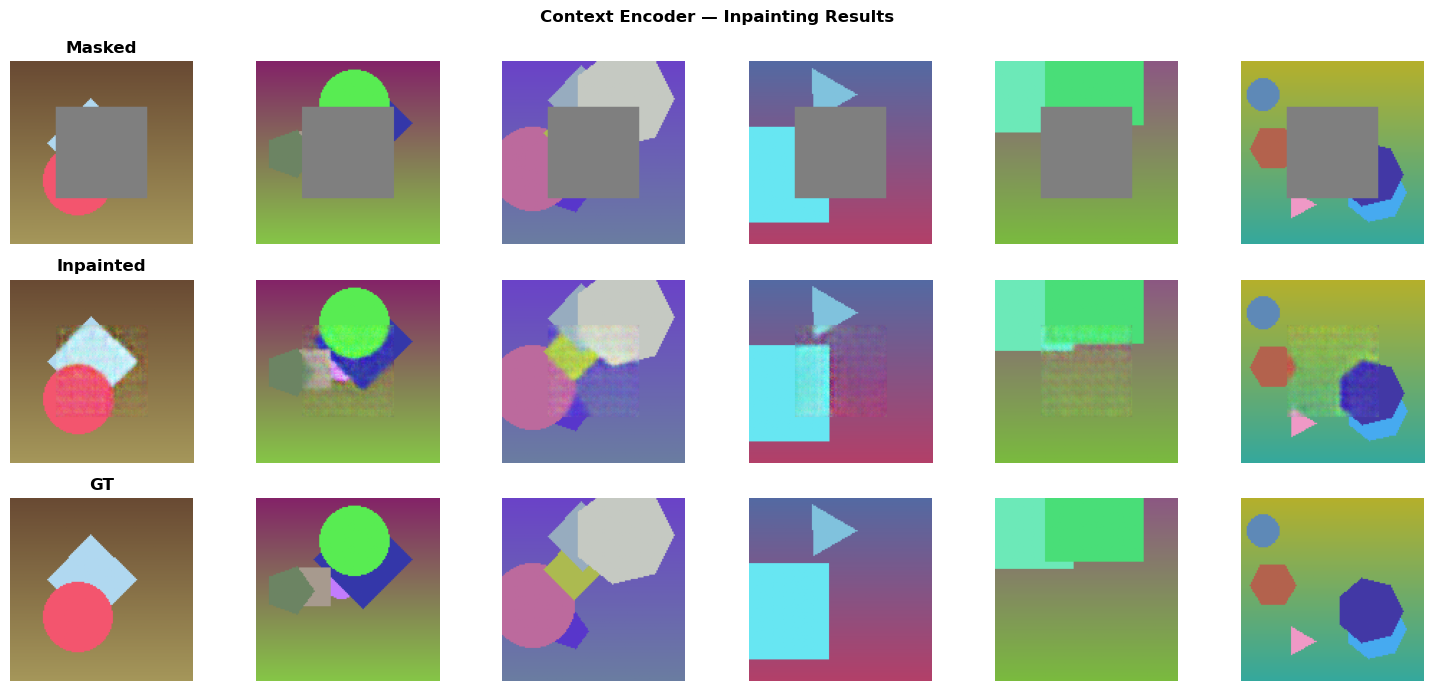

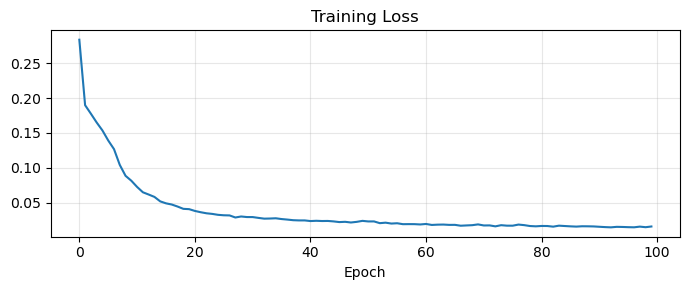

In [6]:
# ── Results ───────────────────────────────────────────────────────────────────
E.eval(); D.eval()
masked, gt, full = next(iter(loader))
with torch.no_grad(): pred = D(E(masked[:6].to(device))).cpu()
s, e = (IMG-HOLE)//2, (IMG-HOLE)//2+HOLE
composed = masked[:6].clone(); composed[:,:,s:e,s:e] = pred
dn = lambda t: (t*.5+.5).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(3,6,figsize=(15,7))
for i in range(6):
    for j,(img,ttl) in enumerate(zip([masked[i],composed[i],full[i]],['Masked','Inpainted','GT'])):
        axes[j,i].imshow(dn(img)); axes[j,i].axis('off')
        if i==0: axes[j,i].set_title(ttl, fontweight='bold')
plt.suptitle('Context Encoder — Inpainting Results', fontweight='bold'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3))
plt.plot(history); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()